# Example of usage of open_space code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [130]:
from cases.open_space.ngsolve_geometries import CleanCircle

R = 1.
r = 0.2


Lc = 0.5
lc = 0.5

mesh = CleanCircle(R=R, verbosity=0, Lc=Lc)


In [131]:
mesh.n_triangles

24

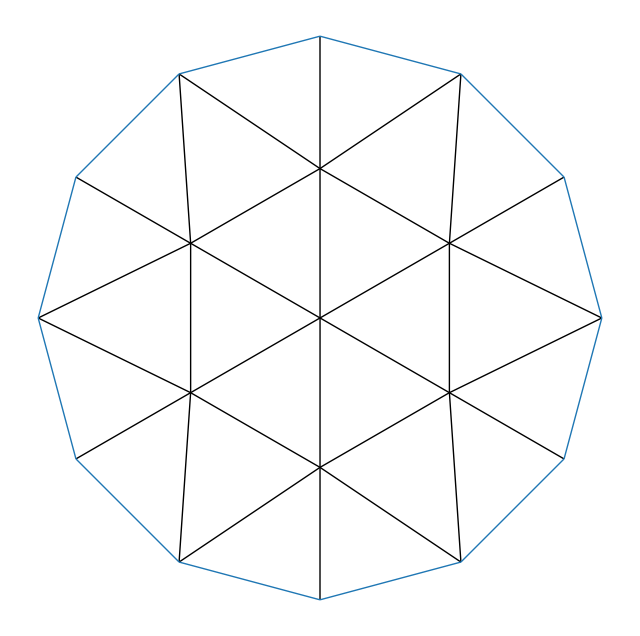

In [132]:
from cases.open_space.plot import plot_openspace
plot_openspace(mesh)

In [133]:
Boundaries = mesh.boundaries
list(Boundaries)

[<Boundaries.SIGMA: 'Sigma'>, <Boundaries.D_OMEGA: 'd_Omega'>]

In [134]:
# mesh.curve_boundaries([Boundaries.SIGMA, Boundaries.D_OMEGA], radius=[R,r])
mesh.curve_boundaries([Boundaries.SIGMA], radius=[R])

mesh.curved_boundaries


[<Boundaries.SIGMA: 'Sigma'>]

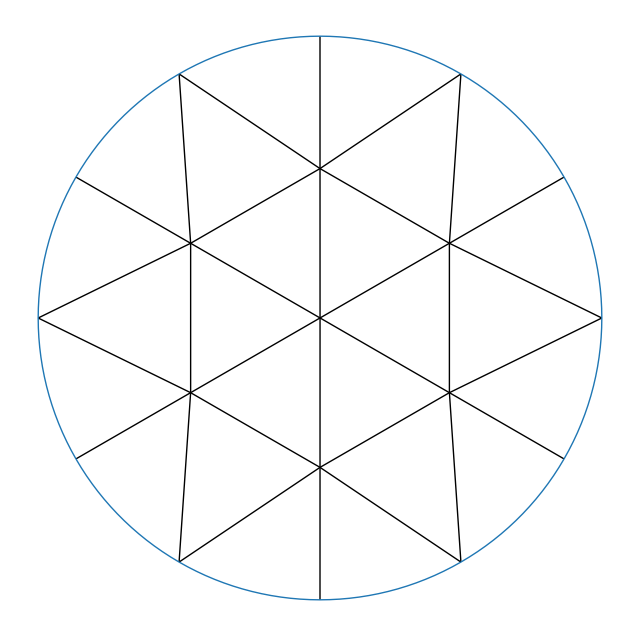

In [135]:
plot_openspace(mesh)

In [140]:
edge

np.void(([0.0, -1.0], [0.4999983478110412, -0.8660263576740775], [0.9659260731738422, 0.25881812371424295], [0.25881812371424295, -0.9659260731738422], [0.2499991739055206, -0.9330131788370388], 0.5176362474284864, True, -1, [ 0, -1]), dtype=[('P', '<f8', (2,)), ('Q', '<f8', (2,)), ('T', '<f8', (2,)), ('N', '<f8', (2,)), ('M', '<f8', (2,)), ('l', '<f8'), ('on_boundary', '?'), ('region', 'i1'), ('triangles', '<i4', (2,))])

In [142]:
for edge in mesh.boundary_Edges[Boundaries.SIGMA]:
    print(f'{edge["theta_1"]=}, {edge["theta_2"]=}')

edge["theta_1"]=np.float64(-1.5707963267948966), edge["theta_2"]=np.float64(-1.0471994589790274)
edge["theta_1"]=np.float64(-1.0471994589790274), edge["theta_2"]=np.float64(-0.5235968678158691)
edge["theta_1"]=np.float64(-0.5235968678158691), edge["theta_2"]=np.float64(2.220446049250313e-16)
edge["theta_1"]=np.float64(0.0), edge["theta_2"]=np.float64(0.5235968678158692)
edge["theta_1"]=np.float64(0.5235968678158692), edge["theta_2"]=np.float64(1.0471994589790274)
edge["theta_1"]=np.float64(1.0471994589790274), edge["theta_2"]=np.float64(1.5707963267948968)
edge["theta_1"]=np.float64(1.5707963267948966), edge["theta_2"]=np.float64(2.094393194610766)
edge["theta_1"]=np.float64(2.094393194610766), edge["theta_2"]=np.float64(2.6179957857739242)
edge["theta_1"]=np.float64(2.6179957857739242), edge["theta_2"]=np.float64(3.1415926535897927)
edge["theta_1"]=np.float64(3.141592653589793), edge["theta_2"]=np.float64(3.6651895214056625)
edge["theta_1"]=np.float64(-2.617995785773924), edge["theta_

To that regions we can apply different boundary conditions. In our case we will set a radiant boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [102]:
from trefftz.dg.boundary_conditions import NtDBC

In [103]:
import numpy as np
from trefftz.dg.exact import PlaneWave
k = 8.0
planewave = PlaneWave(d=np.array([-1., 0.]), A=-1., k=k)
data = planewave
boundary_conditions = {Boundaries.SIGMA: NtDBC(truncating_radius=R, data=data)}


Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [104]:
from trefftz.dg.block_fluxes import UltraWeakFlux


as well as specific ones (for a circular NtD map):

In [105]:
from cases.open_space.block_fluxes import NtDLocal, NtDNonLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [106]:
from trefftz.dg.assemblers import BlockNumerics
NtD_modes = 15
a = 0.5
b = 0.5
d2 = 0.5


numerics = BlockNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
                          local_boundary_kernels={ NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=data)},
                          nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = data)})

We should also choose a local basis

In [107]:
from trefftz.dg.basis import LinearlySpacedBasis
from trefftz.dg.parameters import Elementwise

Regions = mesh.regions


refractive_index = Elementwise(mesh, {Regions.BACKGROUND: 1., Regions.OMEGA : 1.})
Ntheta = 14
basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, refractive_index=refractive_index, k=k, N_theta=Ntheta)

and an assembler:

In [108]:
basis.N_DOF

2324

In [109]:
from trefftz.dg.assemblers import BlockAssembler

assembler = BlockAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

In [110]:
assembler._regions_RHS_term

[<Boundaries.SIGMA: 'Sigma'>]

so we can set the problem:

In [111]:
from trefftz.problem import Problem


P = Problem(mesh=mesh,
            wavenumber=k,
            basis=basis,
            boundary_conditions=boundary_conditions,
            assembler=assembler,
            direct_solver=True,
            u=lambda x, y: planewave(x, y))

In [112]:
P.assemble_LHS()

assembling local operators
region: Sigma


Interior: 100%|██████████| 233/233 [00:00<00:00, 1365.53edge/s]


assembling non-local operators


NtD, Sigma: 100%|██████████| 32/32 [05:55<00:00, 11.11s/edge]


<COOrdinate sparse array of dtype 'complex128'
	with 389648 stored elements and shape (2324, 2324)>

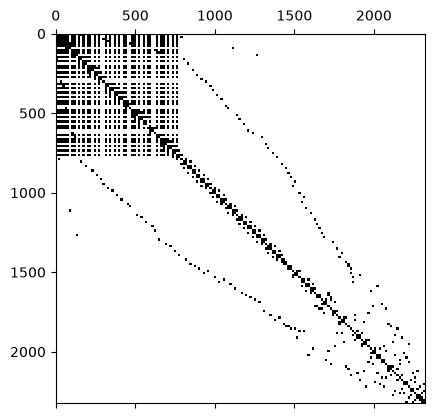

In [124]:
import matplotlib.pyplot as plt 
plt.spy(P.A.toarray())

In [125]:
P.assemble_RHS()

array([ 0.36747099+0.13285856j, -0.26636398+0.00540346j,
        0.20969473-0.32257083j, ...,  0.        +0.j        ,
        0.        +0.j        ,  0.        +0.j        ], shape=(2324,))

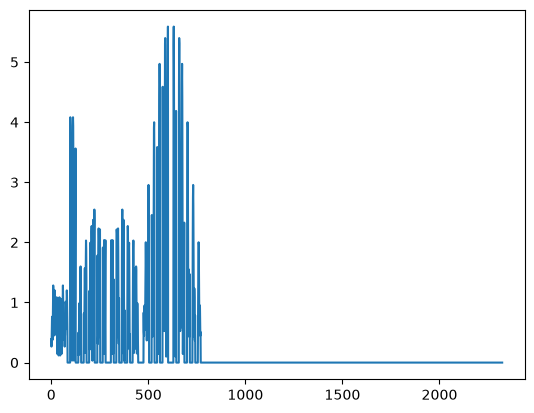

In [126]:
import numpy as np 
plt.plot(np.abs(P.b))

In [127]:
P.solve()

In [128]:
P.u_h.coefficients.reshape((-1,Ntheta))

array([[nan+0.j, nan+0.j, nan+0.j, ..., nan+0.j, nan+0.j, nan+0.j],
       [nan+0.j, nan+0.j, nan+0.j, ..., nan+0.j, nan+0.j, nan+0.j],
       [nan+0.j, nan+0.j, nan+0.j, ..., nan+0.j, nan+0.j, nan+0.j],
       ...,
       [nan+0.j, nan+0.j, nan+0.j, ..., nan+0.j, nan+0.j, nan+0.j],
       [nan+0.j, nan+0.j, nan+0.j, ..., nan+0.j, nan+0.j, nan+0.j],
       [nan+0.j, nan+0.j, nan+0.j, ..., nan+0.j, nan+0.j, nan+0.j]],
      shape=(166, 14))

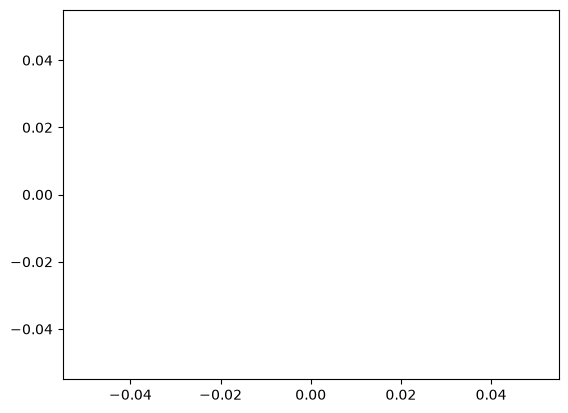

In [129]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

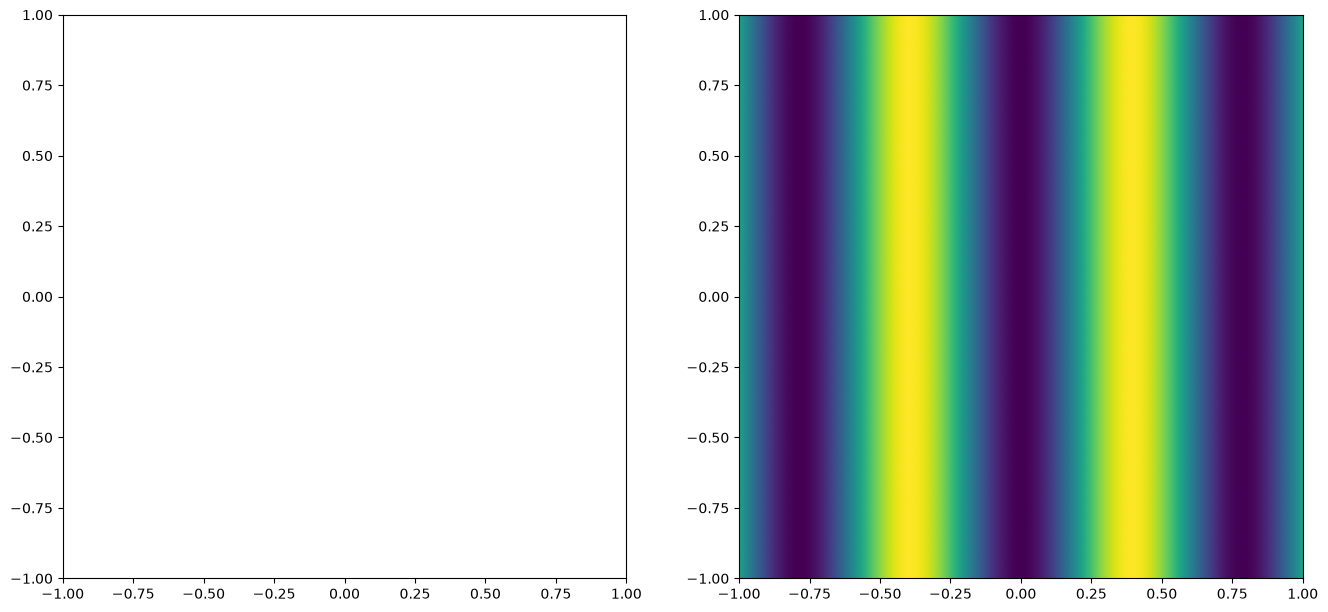

In [119]:
import numpy as np
import matplotlib.pyplot as plt

N = 200
x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)

X, Y = np.meshgrid(x,y)

U_h = P.u_h(X, Y)
U = P.u(X, Y)
fig, ax = plt.subplots(ncols=2, figsize=(16,8))
vmin = np.min(U.real)
vmax = np.max(U.real)


ax[0].pcolormesh(X, Y, np.real(U_h), vmin=-1, vmax=1, shading="gouraud")
ax[0].axis('square')

ax[1].pcolormesh(X, Y, np.real(U), vmin=-1, vmax=1, shading="gouraud")
ax[1].axis('square')


(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

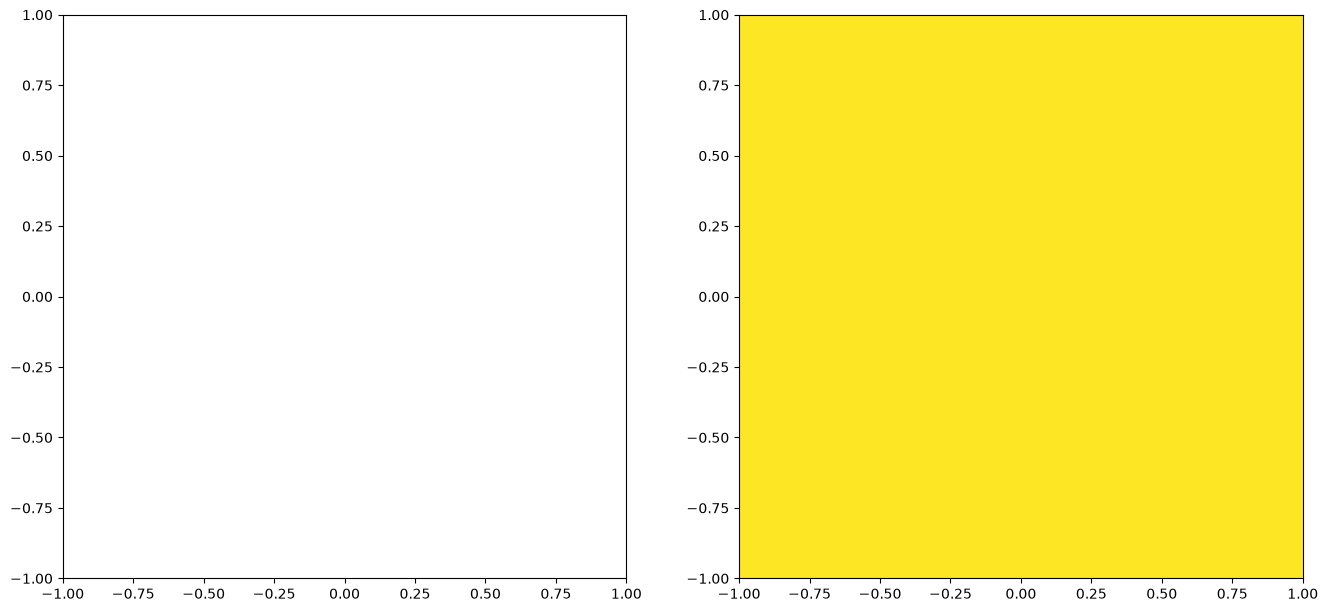

In [120]:
fig, ax = plt.subplots(ncols=2, figsize=(16,8))

ax[0].pcolormesh(X, Y, np.abs(U_h), vmin=0, vmax=1, shading="gouraud")
ax[0].axis('square')

ax[1].pcolormesh(X, Y, np.abs(U), vmin=0, vmax=1, shading="gouraud")
ax[1].axis('square')


nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan


Text(0.5, 1.0, 'nan')

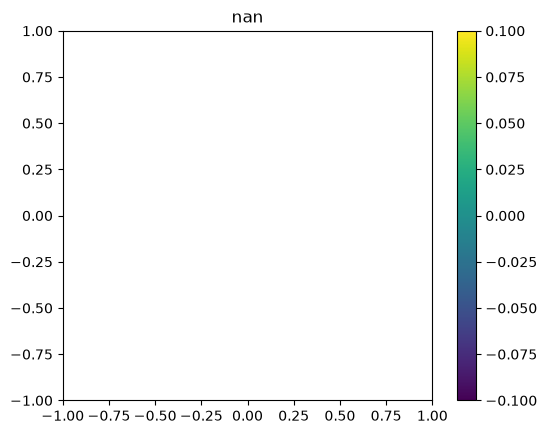

In [121]:
plt.pcolormesh(X, Y, np.abs(U - U_h), shading="gouraud")
plt.axis("square")
plt.colorbar()
plt.title(P.compute_error())